In [1]:
# combine RC and RS into one file
import json
import os

comment_path = r"F:\ERP_data\final_corpusRC_06.jsonl"
submission_path = r"F:\ERP_data\final_corpusRS_05.jsonl"
output_path = r"F:\ERP_data\final_corpusRCRS.jsonl"

comment_count = 0
submission_count = 0
total_count = 0

with open(output_path, "w", encoding="utf-8") as fout:

    # Comments
    with open(comment_path, "r", encoding="utf-8") as fin:
        for line in fin:
            obj = json.loads(line)
            body = (obj.get("body") or "").strip()
            if not body:
                continue

            obj["text_for_analysis"] = body

            obj["source_type"] = "comment"

            fout.write(
                json.dumps(
                    obj,
                    ensure_ascii=False
                ) + "\n"
            )

            comment_count += 1
            total_count += 1

    # Submissions
    with open(submission_path, "r", encoding="utf-8") as fin:

        for line in fin:

            obj = json.loads(line)

            text = (
                obj.get("text_for_analysis")
                or ""
            ).strip()

            if not text:
                title = obj.get("title") or ""
                selftext = obj.get("selftext") or ""
                text = (
                    title + " " + selftext
                ).strip()

            if not text:
                continue

            obj["text_for_analysis"] = text
            obj["source_type"] = "submission"

            fout.write(
                json.dumps(
                    obj,
                    ensure_ascii=False
                ) + "\n"
            )

            submission_count += 1
            total_count += 1

print("Saved:", output_path)
print()
print("Comments:", comment_count)
print("Submissions:", submission_count)
print("Total corpus:", total_count)

Saved: F:\ERP_data\final_corpusRCRS.jsonl

Comments: 1932
Submissions: 474
Total corpus: 2406


In [4]:
# Remove pure URL
import json
import re

input_path = r"F:\ERP_data\final_corpusRCRS.jsonl"
output_path = r"F:\ERP_data\final_corpusRCRS_clean.jsonl"

url_pattern = re.compile(
    r"^(https?://\S+|www\.\S+)$",
    re.I
)

total = 0
removed = 0
kept = 0

with open(input_path, "r", encoding="utf-8") as fin, \
     open(output_path, "w", encoding="utf-8") as fout:

    for line in fin:
        obj = json.loads(line)
        total += 1
        text = (
            obj.get("text_for_analysis") 
            or ""
        ).strip()

        if url_pattern.match(text):
            removed += 1
            continue

        fout.write(
            json.dumps(
                obj,
                ensure_ascii=False
            ) + "\n"
        )

        kept += 1

print("Total:", total)
print("Removed pure URL:", removed)
print("Kept:", kept)
print("Saved:", output_path)

Total: 2406
Removed pure URL: 2
Kept: 2404
Saved: F:\ERP_data\final_corpusRCRS_clean.jsonl


In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
path = r"F:\ERP_data\final_corpusRCRS_clean.jsonl"


data = []

with open(path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))


df = pd.DataFrame(data)


keep_cols = [
    "text_for_analysis",
    "source_type",
    "subreddit",
    "classifier_probability",
    "created_utc"
]


df = df[
    [
        c for c in keep_cols
        if c in df.columns
    ]
]

print("Total documents:", len(df))

print("\nSource distribution:")
print(df["source_type"].value_counts())


df.head()

Total documents: 2404

Source distribution:
source_type
comment       1930
submission     474
Name: count, dtype: int64


,text_for_analysis,source_type,subreddit,classifier_probability,created_utc
0,"Most males don't want to be nurses, because mo...",comment,PS4,0.623545,1554078921
1,What are you talking about? Professors get pai...,comment,PS4,0.638609,1554083849
2,Not all. A couple of the women I work with (in...,comment,metacanada,0.656779,1554087721
3,Bitch I went from a U to a grade 5 in a month ...,comment,IncelTears,0.647230,1554114790
4,Here's something a lot of people don't know: i...,comment,WhereAreAllTheGoodMen,0.663537,1554121182


In [13]:
# word count
df["word_count"] = (
    df["text_for_analysis"]
    .str.split()
    .str.len()
)


df.groupby("source_type")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
source_type,,,,,,,,
comment,1930.0,118.798964,146.366470,1.0,35.0,72.0,142.75,1304.0
submission,474.0,123.132911,225.552967,5.0,12.0,28.0,133.00,2453.0


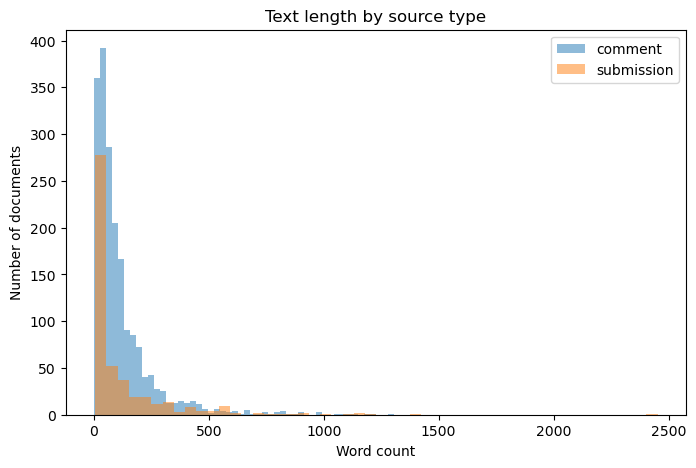

In [9]:
# word count visualisation
plt.figure(figsize=(8,5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.title("Text length distribution")

plt.show()

subreddit
unpopularopinion     457
pics                 120
MensRights            80
AskReddit             58
MGTOW                 54
TwoXChromosomes       50
videos                43
worldnews             42
GenderCritical        37
AskFeminists          34
AskMen                30
canada                30
JordanPeterson        29
The_Donald            25
Braincels             24
news                  23
quityourbullshit      22
ApplyingToCollege     21
PurplePillDebate      20
KotakuInAction        16
Name: count, dtype: int64


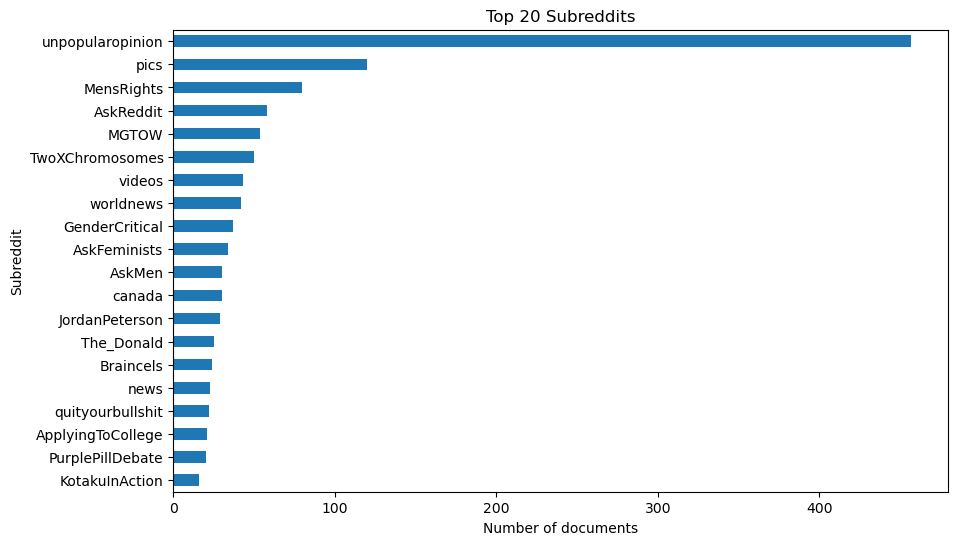

In [11]:
# subreddit distribution
top_subreddits = (
    df["subreddit"]
    .value_counts()
    .head(20)
)


print(top_subreddits)

plt.figure(figsize=(10,6))


top_subreddits.sort_values().plot(
    kind="barh"
)


plt.xlabel("Number of documents")
plt.ylabel("Subreddit")
plt.title("Top 20 Subreddits")


plt.show()

In [14]:
# subreddit differences
(
    df.groupby("source_type")["subreddit"]
    .value_counts()
    .groupby(level=0)
    .head(10)
)

source_type  subreddit        
comment      unpopularopinion     432
             pics                 120
             MensRights            73
             AskReddit             51
             MGTOW                 44
             videos                43
             worldnews             41
             TwoXChromosomes       40
             AskMen                30
             GenderCritical        29
submission   unpopularopinion      25
             AutoNewspaper         13
             MGTOW                 10
             TwoXChromosomes       10
             ApplyingToCollege      9
             newsbotbot             9
             GenderCritical         8
             AskReddit              7
             MensRights             7
             AskFeminists           6
Name: count, dtype: int64

In [15]:
#high-frequency words
import re
from collections import Counter


all_text = " ".join(
    df["text_for_analysis"]
    .astype(str)
)


words = re.findall(
    r"\b[a-zA-Z]{3,}\b",
    all_text.lower()
)


stopwords = set([
    "the","and","that","this",
    "with","for","are","was",
    "you","not","but","have",
    "they","from","women",
    "woman"
])


words_filtered = [
    w for w in words
    if w not in stopwords
]


freq = Counter(words_filtered)


freq.most_common(30)

[('stem', 3409),
 ('men', 2856),
 ('more', 2137),
 ('there', 1523),
 ('because', 1349),
 ('like', 1238),
 ('about', 1180),
 ('just', 1170),
 ('all', 1123),
 ('don', 1113),
 ('fields', 1088),
 ('who', 1021),
 ('can', 1007),
 ('female', 996),
 ('into', 984),
 ('their', 981),
 ('what', 978),
 ('people', 927),
 ('than', 914),
 ('get', 849),
 ('gender', 831),
 ('male', 792),
 ('work', 789),
 ('them', 765),
 ('think', 760),
 ('would', 758),
 ('being', 740),
 ('want', 724),
 ('she', 722),
 ('when', 710)]

In [16]:
#gender/stem key words
keywords = [
    "women",
    "woman",
    "female",
    "girls",
    "gender",
    "sexism",
    "bias",
    "engineering",
    "engineer",
    "coding",
    "programming",
    "computer",
    "science",
    "stem",
]


for k in keywords:

    count = (
        df["text_for_analysis"]
        .str.lower()
        .str.contains(k)
        .sum()
    )

    print(
        k,
        ":",
        count
    )

women : 1996
woman : 469
female : 645
girls : 391
gender : 533
sexism : 156
bias : 102
engineering : 421
engineer : 510
coding : 78
programming : 93
computer : 181
science : 426
stem : 1910
